In [91]:
### libraries
library(data.table)
library(tidyverse)
library(ggrepel)
library(patchwork)

In [92]:
source("../workflow/scripts/init.R")
source("../workflow/scripts/QN_functions.R")

In [93]:
theme_set(theme_bw())

In [94]:
cava1_dir <- "<path_to_processed_data>/human_cava_cohort_plasma_1/"
cava2_dir <- "<path_to_processed_data>/human_cava_cohort_plasma_2/"

In [95]:
outdir <- "<path_to_processed_data>/human_cava_1_cava_2/"
dir.create(outdir)

Warning message in dir.create(outdir):
“'/nobackup/lab_bock/users/dromanovskaia/projects/peptide_array/processed_data/HUMAN/human_cava_1_cava_2' already exists”


In [161]:
colors_significance <- c("cava1" = "#1a9850", "cava2" = "#a6cee3",
                       "both" = "#fb9a99", 
                         "none" = "grey")

In [171]:
sex <- "Female"

In [172]:
dir.create(file.path(outdir, paste0("volcano_", sex)))

In [174]:
df_1 <- read_volcano_df(file.path(cava1_dir, "volcano", paste0("By_Sex_", sex), 
                                   "Gensini", "logFC_df.csv"), "cava1")

In [175]:
df_2 <- read_volcano_df(file.path(cava2_dir, "volcano", paste0("By_Sex_", sex), 
                                   "Gensini", "logFC_df.csv"), "cava2")

In [176]:
combined_df <- full_join(df_1, df_2)

Joining with `by = join_by(coordinate_unique, sequence_label,
sequence_label_short)`


In [177]:
head(combined_df)

coordinate_unique,sequence_label,sequence_label_short,log2fc_cava1,pval_cava1,log2fc_cava2,pval_cava2
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
L1_C1_L1,AGRPK-Cell wall surface anchor family protein (Streptococcus oralis),AGRPK,0.10541464,0.86463519,-0.7675887,0.03615083
L2_C1_L1,TSDVEVNEKKERVTEA-Other Human (human) protein (Human),TSDVEVNEKKERVTEA,0.38428796,0.27670877,-0.2717263,0.33963448
L3_C1_L1,IANVFTNAFR-Myeloperoxidase (Human),IANVFTNAFR,-0.44871865,0.31526142,-0.2176818,0.29415758
L4_C1_L1,WDGERLYQEA-Myeloperoxidase (Human),WDGERLYQEA,-0.75542465,0.02742291,-0.2710802,0.12501757
L5_C1_L1,VARALAHGVRVLEDGVNFAT-Genome polyprotein (Hepatitis C virus),VARALAHGVRVLEDGVNFAT,0.10792233,0.78107934,-0.2401622,0.35153682
L6_C1_L1,LWDQTYGVPD-Protein BOLF1 (Human herpesvirus 4 (Epstein Barr virus)),LWDQTYGVPD,0.09062947,0.81948162,-0.1492903,0.37731196


In [178]:
combined_df$sign <- "none"

combined_df[pval_cava1 < 0.05, sign:= "cava1",]

combined_df[pval_cava2 < 0.05, sign:= "cava2",]

combined_df[pval_cava2 < 0.05 & pval_cava1 < 0.05, sign:= "both",]

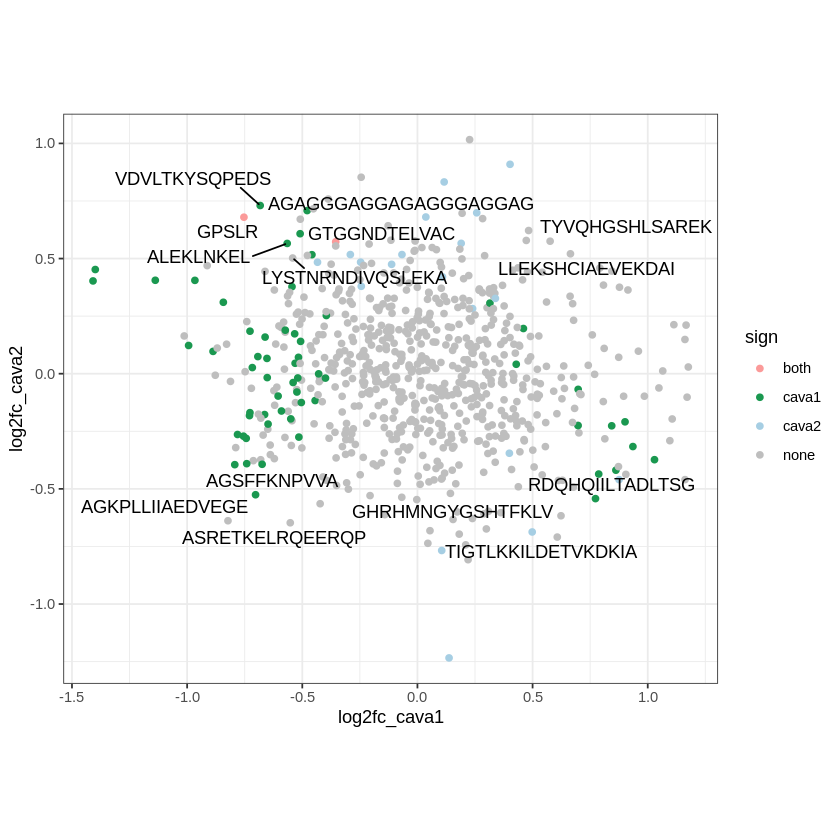

In [179]:
ggplot(combined_df, aes(x = log2fc_cava1, y = log2fc_cava2)) + geom_point(aes( color = sign)) + 
    coord_equal() + 
    scale_color_manual(values = colors_significance) + 
     geom_text_repel(data = combined_df[(abs(log2fc_cava1) > 0.5 & abs(log2fc_cava2) > 0.5) ], 
                        aes(x = log2fc_cava1, y = log2fc_cava2, label = sequence_label_short))
 ggsave(file.path(outdir,  paste0("volcano_", sex),  "logFC_compare.pdf"), width = 8, height = 8)

In [180]:
write.csv(combined_df, file.path(outdir,  paste0("volcano_", sex),  "logFC_combined.csv"))

### merging data and metadata to create a combined file for correlations and differential analysis

In [99]:
df_cava1 <- fread(file.path(cava1_dir, "normalised_quantiles","full_samples_normalised.csv"))
df_cava1

14620_10,14620_11,14620_12,14620_16,14620_19,14620_24,14620_26,14620_29,14620_31,14620_34,⋯,15328_86,15328_93,15731_11,15731_13,15731_4,15731_9,coordinate_unique,sequence_label,library,color_col
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
0.10255245,0.26636625,0.31564754,0.32151685,0.08098795,0.82283277,0.18146753,0.17871988,0.07200937,0.43712414,⋯,0.35819826,0.24027089,0.09184960,0.09184960,0.43035609,0.26636625,L1_C1_L1,AGRPK-Cell wall surface anchor family protein (Streptococcus oralis),L1,group
0.04158947,0.04679374,0.07996378,0.12590368,0.06056272,0.11312925,0.11154620,0.04995371,0.05731282,0.10515605,⋯,0.05102883,0.07868603,0.05531864,0.07280369,0.07736341,0.06556058,L2_C1_L1,TSDVEVNEKKERVTEA-Other Human (human) protein (Human),L1,group
0.09289305,0.05142525,0.13258486,0.14051144,0.09559123,0.23495384,0.27690260,0.12623498,0.06525497,0.28082509,⋯,0.14160947,0.15076381,0.06260283,0.10658486,0.06380925,0.06944388,L3_C1_L1,IANVFTNAFR-Myeloperoxidase (Human),L1,group
0.15838860,0.14934334,0.12293076,0.28194775,0.11366774,0.37337445,0.15464221,0.21164923,0.13728152,0.30666862,⋯,0.10368729,0.14051144,0.09265748,0.15838860,0.16174966,0.23076589,L4_C1_L1,WDGERLYQEA-Myeloperoxidase (Human),L1,group
0.13258486,0.11182878,0.08933357,0.17789030,0.15616270,0.12886169,0.12527309,0.12735856,0.08883181,0.08235072,⋯,0.14011626,0.12651472,0.09582676,0.14160947,0.19639557,0.20411184,L5_C1_L1,VARALAHGVRVLEDGVNFAT-Genome polyprotein (Hepatitis C virus),L1,group
0.20752065,0.23076589,0.11446129,0.25918459,0.26030239,0.17789030,0.22363798,0.32930902,0.14562267,0.62299204,⋯,0.19232477,0.49714767,0.20160488,0.16870568,0.37099915,0.29573478,L6_C1_L1,LWDQTYGVPD-Protein BOLF1 (Human herpesvirus 4 (Epstein Barr virus)),L1,group
0.18248833,0.07496541,0.13529832,0.10815293,0.14599171,0.15900436,0.28309524,0.14631278,0.09315009,0.13258486,⋯,0.22494761,0.20298920,0.15943394,0.17460595,0.13789411,0.08835088,L8_C1_L1,IGSTPIGDS-Other Mycobacterium avium protein (Mycobacterium avium),L1,group
0.06204168,0.11287277,0.05554495,0.11392666,0.12230296,0.19136296,0.10586462,0.08764650,0.11128794,0.09449462,⋯,0.05588292,0.17871988,0.10612395,0.21795729,0.16832667,0.31224609,L9_C1_L1,GVTLLQAAPT-60 kDa chaperonin 2 (UniProt:P9WPE7) (Mycobacterium tuberculosis),L1,group
0.05963533,0.11210725,0.07200937,0.16660912,0.37337445,0.19690496,0.75320351,0.16832667,0.11794618,0.07226706,⋯,0.10862780,0.11094204,0.49714767,0.22363798,0.14666419,0.12763108,L10_C1_L1,QRAKEALDKYELENH-UniProt:A2RGM0 (Streptococcus pyogenes),L1,group


In [100]:
df_cava2 <- fread(file.path(cava2_dir, "normalised_quantiles","full_samples_normalised.csv"))
df_cava2

15328_101,15328_102,15328_113,15328_117,15328_118,15328_120,15328_143,15328_152,15328_155,15328_160,⋯,15328_493,15328_498,15328_53,15328_58,15328_81,15328_98,coordinate_unique,sequence_label,library,color_col
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
0.29361222,0.41371629,0.15626687,0.38140781,0.30879827,0.16745698,0.19785180,0.37633323,0.19646602,0.20178827,⋯,0.90163879,0.36888412,0.23872311,0.21451139,0.13599681,0.18829502,L1_C1_L1,AGRPK-Cell wall surface anchor family protein (Streptococcus oralis),L1,group
0.07426351,0.06583628,0.04897110,0.05653875,0.07898048,0.14952535,0.08269780,0.07137655,0.05050030,0.10729505,⋯,0.05757949,0.07661802,0.08336360,0.07271121,0.03751129,0.03922478,L2_C1_L1,TSDVEVNEKKERVTEA-Other Human (human) protein (Human),L1,group
0.12846687,0.09403487,0.19900107,0.14717318,0.12722996,0.05171049,0.12822662,0.22636771,0.11715840,0.37380412,⋯,0.16492294,0.11468226,0.08989884,0.17204680,0.15739050,0.11792899,L3_C1_L1,IANVFTNAFR-Myeloperoxidase (Human),L1,group
0.55358431,0.20969304,0.60443717,0.27239264,0.53840054,0.29361222,0.61382524,0.56706645,0.27894156,0.42055354,⋯,0.95752803,0.90163879,0.53840054,0.47476174,0.55358431,0.74187544,L4_C1_L1,WDGERLYQEA-Myeloperoxidase (Human),L1,group
0.11040857,0.10375894,0.17341023,0.09445945,0.12616378,0.32092822,0.26998776,0.21848053,0.08876847,0.16281747,⋯,0.32092822,0.10729505,0.16461225,0.14825634,0.11916427,0.12389608,L5_C1_L1,VARALAHGVRVLEDGVNFAT-Genome polyprotein (Hepatitis C virus),L1,group
0.54552554,0.53119893,0.64626928,0.26022989,0.57422639,0.27239264,0.75520744,0.76937136,0.58765765,0.87790617,⋯,0.87790617,0.75520744,0.45253624,0.95752803,0.87790617,0.48523867,L6_C1_L1,LWDQTYGVPD-Protein BOLF1 (Human herpesvirus 4 (Epstein Barr virus)),L1,group
0.12973986,0.05757949,0.21026715,0.08202168,0.13801731,0.24364404,0.15930555,0.14661206,0.23684351,0.13259835,⋯,0.16125801,0.09774668,0.11843821,0.11843821,0.12277012,0.13726364,L8_C1_L1,IGSTPIGDS-Other Mycobacterium avium protein (Mycobacterium avium),L1,group
0.23110254,0.04370834,0.18732230,0.13459994,0.13141500,0.06504823,0.16200988,0.22399874,0.10006778,0.11569449,⋯,0.10332484,0.07137655,0.12150644,0.13978452,0.09427349,0.14595784,L9_C1_L1,GVTLLQAAPT-60 kDa chaperonin 2 (UniProt:P9WPE7) (Mycobacterium tuberculosis),L1,group
0.11257281,0.08746179,0.10782742,0.05499082,0.13633157,0.19120269,0.06558005,0.10657232,0.06876075,0.15233830,⋯,0.07605636,0.12796356,0.07426351,0.07298135,0.08557365,0.10310152,L10_C1_L1,QRAKEALDKYELENH-UniProt:A2RGM0 (Streptococcus pyogenes),L1,group


In [101]:
df_full <- full_join(df_cava1, df_cava2)

Joining with `by = join_by(coordinate_unique, sequence_label, library,
color_col)`


In [102]:
cava1_long <- pivot_longer(df_cava1, !c(coordinate_unique, sequence_label, library, color_col))
cava1_long$cava <- "cava1"

In [103]:
cava2_long <- pivot_longer(df_cava2, !c(coordinate_unique, sequence_label, library, color_col))
cava2_long$cava <- "cava2"

In [104]:
cava_long <- rbind(cava1_long, cava2_long)

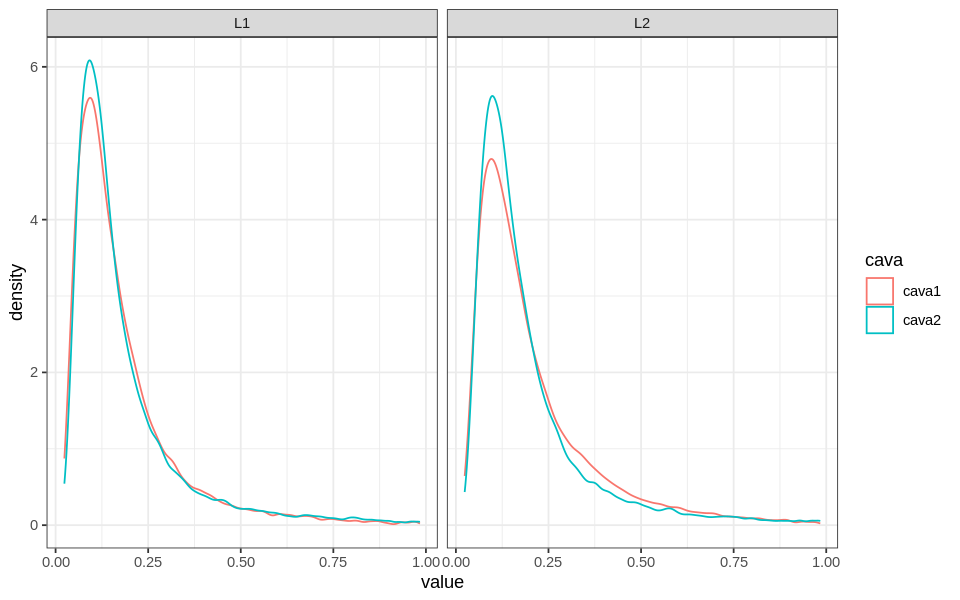

In [105]:
options(repr.plot.width = 8, repr.plot.height = 5)
ggplot(cava_long, aes(x = value, color = cava)) + geom_density(fill = NA) + facet_wrap(~library)

`summarise()` has grouped output by 'cava', 'library'. You can override using
the `.groups` argument.
Warning message:
“ggrepel: 685 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


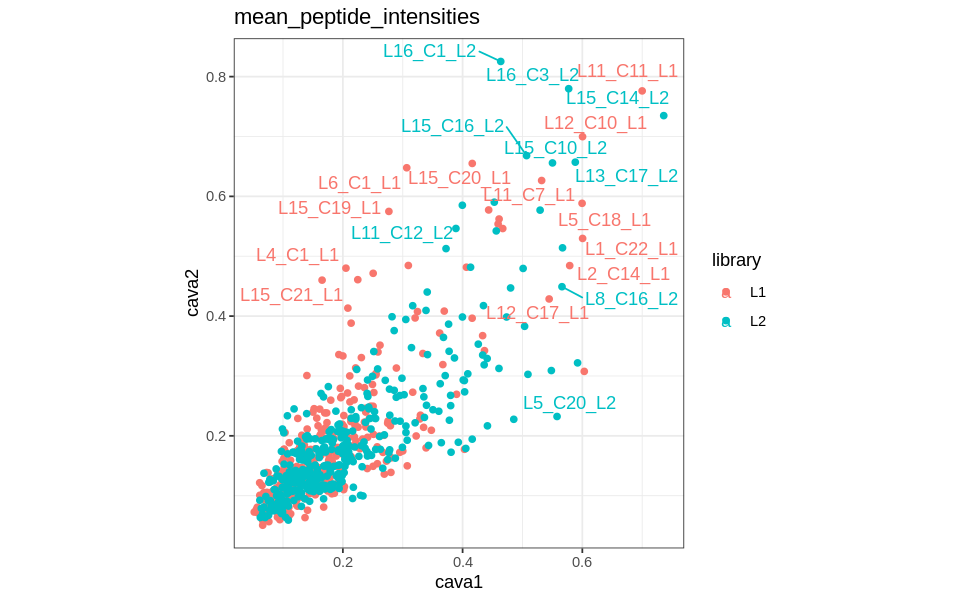

In [28]:
cava_long %>% group_by(cava, library, coordinate_unique) %>%
    summarize(mean_int = mean(value)) %>% 
    pivot_wider(values_from = mean_int, names_from = cava) %>%
    ggplot() + aes(x = cava1, y = cava2, color = library) + 
        geom_point() + coord_equal() + 
    geom_text_repel(aes(label = coordinate_unique)) + 
    ggtitle("mean_peptide_intensities")

In [29]:
dir.create(file.path(outdir, "combined_analysis", "normalised_quantiles"), recursive = TRUE)

In [31]:
my_wt(df_full, file.path(outdir, "combined_analysis", "normalised_quantiles", "full_samples_normalised.csv"))

In [109]:
annot_df <- as.data.frame(unique(cava_long[,c('name', 'cava')]))

In [110]:
colnames(annot_df)[1] <- 'sample_name'

In [111]:
cols_to_use <- annot_df$sample_name

In [112]:
annot_df$organism <- "human"

In [113]:
annot_df$tissue <- "plasma"

In [18]:
write.table(annot_df,
     "../config/human_cava_cohort_combined.csv",
           sep = ",", quote = F, row.names = F)

### merged annotation

In [114]:
annot_cava_1 <- fread("/research/home/dromanovskaia/projects/justine/peptide_array/metadata/Clinical_data_CAVA_COHORT_JD_all_parameter_full.csv")

In [115]:
annot_cava_2 <- fread("/home/dromanovskaia/projects/justine/peptide_array/metadata/Justine_clinical_data_CAVA_cohort2_2025.csv")

In [116]:
### clean up metadata
colnames(annot_cava_2) <- gsub("Event Name", "Event name", colnames(annot_cava_2))

In [117]:
colnames(annot_cava_2) <- gsub("Maximum Stenosis \\(%\\)", "MaximumStenosis%", colnames(annot_cava_2))

In [118]:
colnames(annot_cava_2) <- gsub("TAV \\(mm2\\)", "TAVmm2", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Fatty \\(%\\)", "Fatty%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Atheroma Burden \\(%\\)", "AtheromaBurden%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Fibrous \\(%\\)", "Fibrous%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Necrotic \\(%\\)", "Necrotic%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Calcium \\(%\\)", "Calcium%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Gensini Score", "GensiniScore", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Fibrous \\(%\\)", "Fibrous%", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Statin", "Statin_use", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Lymphocytes  Absolute Count \\(k\\/uL\\)", "Lymphocytes Absolute Count \\(k\\/uL\\)", colnames(annot_cava_2))
colnames(annot_cava_2) <- gsub("Total Cholesterol \\(mg/dL\\)", "Totalcholesterolmgdl", colnames(annot_cava_2))

In [119]:
annot_cava_1$cava <- "cava1"
annot_cava_2$cava <- "cava2"

In [120]:
annot_cava <- rbind(annot_cava_1, annot_cava_2, fill = TRUE)

In [165]:
write.table(annot_cava,
          sep = ",", 
          quote = FALSE, 
          row.names = FALSE,
          file.path("/home/dromanovskaia/projects/justine/peptide_array/metadata/CAVA_combined.csv"))

In [121]:
annot_cava_2$Sample_full_ID <- gsub('15328_186', '15328_186_cava2',annot_cava_2$Sample_full_ID )

In [123]:
annot_df <- left_join(annot_df, 
          rbind(annot_cava_1[, c("Sample_full_ID", "Sex")], 
                annot_cava_2[, c("Sample_full_ID", "Sex")], fill = TRUE),
          by = c("sample_name" = "Sample_full_ID"))

In [124]:
### making a PCA 
df_rot <- run_pca(df_full[,..cols_to_use], 
                  file.path(outdir, "combined_analysis", "normalised_quantiles"))
df_rot$sample_name <- as.character(row.names(df_rot))
annot_df$sample_name <- as.character(annot_df$sample_name)


In [125]:
df_rot <- left_join(df_rot, annot_df)

Joining with `by = join_by(sample_name)`


Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 50 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


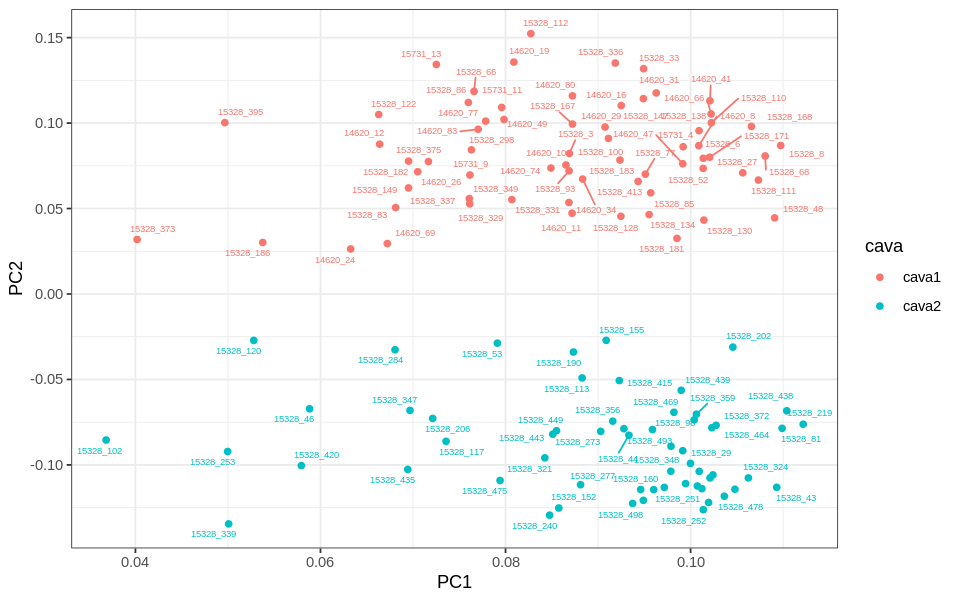

In [126]:
ggplot(df_rot, aes(x = PC1, y = PC2, color = cava)) + geom_point() + 
    geom_text_repel(aes(label = sample_name), size = 2) 
ggsave(file.path(outdir, "combined_analysis", "normalised_quantiles",  "PCA_plot.pdf"), width = 5, height = 5)

In [129]:
desired_cols <- "Sex"

In [130]:
unwanted_categorical_cols <- c("cava")

In [142]:
annot <- data.frame(annot_df[,c(2,5)])

In [139]:
row.names(annot) <- annot_df$sample_name

In [144]:
design <- model.matrix(reformulate(desired_cols), data = annot)

In [145]:
batch <- annot[[unwanted_categorical_cols[1]]]

In [146]:
batch2 <- NULL

In [147]:
covariates <- NULL

In [148]:
library(limma)

In [149]:
# integrate data / remove batch effect
integrated_data <- removeBatchEffect(as.matrix(df_full[,..cols_to_use]), 
                                     batch = batch, 
                                     batch2 = batch2, 
                                     covariates = covariates, 
                                     design = design
                                    )

In [150]:
dir.create(file.path(outdir, "combined_analysis", "normalised_quantiles_corrected"))

Warning message in dir.create(file.path(outdir, "combined_analysis", "normalised_quantiles_corrected")):
“'/nobackup/lab_bock/users/dromanovskaia/projects/peptide_array/processed_data/HUMAN/human_cava_1_cava_2//combined_analysis/normalised_quantiles_corrected' already exists”


In [151]:
df_rot <- run_pca(integrated_data, 
                  file.path(outdir, "combined_analysis", "normalised_quantiles_corrected"))

In [152]:
df_rot$sample_name <- as.character(row.names(df_rot))
df_rot <- left_join(df_rot, annot_df)

Joining with `by = join_by(sample_name)`


Warning message:
“ggrepel: 31 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 69 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


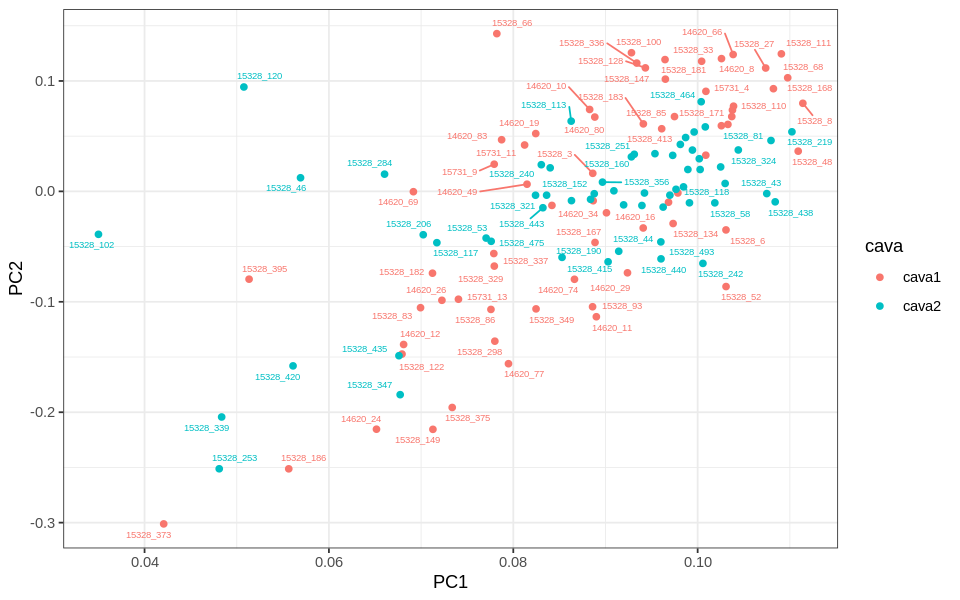

In [153]:
ggplot(df_rot, aes(x = PC1, y = PC2, color = cava)) + geom_point() + 
    geom_text_repel(aes(label = sample_name), size = 2) 
ggsave(file.path(outdir, "combined_analysis", 
                 "normalised_quantiles_corrected",  "PCA_plot.pdf"), width = 5, height = 5)

Warning message:
“ggrepel: 32 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 69 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


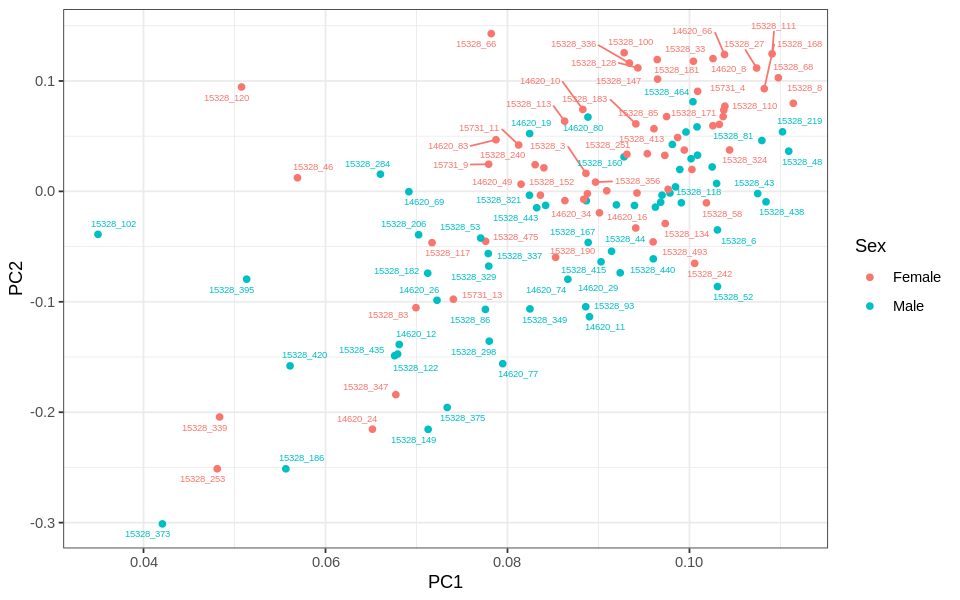

In [154]:
ggplot(df_rot, aes(x = PC1, y = PC2, color = Sex)) + geom_point() + 
    geom_text_repel(aes(label = sample_name), size = 2) 
ggsave(file.path(outdir, "combined_analysis", "normalised_quantiles_corrected",  "PCA_plot_by_Sex.pdf"), width = 5, height = 5)

In [159]:
setdiff(colnames(df_full), colnames(integrated_data))

[1] "coordinate_unique" "sequence_label"    "library"          
[4] "color_col"

In [160]:
integrated_data <- as.data.frame(integrated_data)

In [162]:
integrated_data$coordinate_unique <- df_full$coordinate_unique
integrated_data$sequence_label <- df_full$sequence_label
integrated_data$library <- df_full$library
integrated_data$color_col <- df_full$color_col

In [163]:
my_wt(integrated_data, 
     file.path(outdir, "combined_analysis", "normalised_quantiles", "integrated", "full_samples_normalised.csv"))